<a href="https://colab.research.google.com/github/WVF-1/Cast-and-Crew-Analytics/blob/main/Newsletter_Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Cast, Crew & Keyword Intelligence — Notebook 6
## Newsletter Visualisations & Story

**Series:** May Newsletter — Movie Intelligence (Part 2 of 3)
**Prerequisites:** Run Notebooks 4 & 5 first

### Story arc
> *"We know what makes a movie financially viable. But do the humans behind the camera matter?
> Is it the director's vision, the star on the poster, or the themes buried in the script
> that really separate the hits from the misses?"*

### Figures produced
| Figure | File | Story beat |
|--------|------|------------|
| 1 | `fig7_director_roi.png`        | Top directors by median ROI |
| 2 | `fig8_director_revenue.png`    | Top directors by total box office |
| 3 | `fig9_actor_leaderboard.png`   | Actor profitability leaderboard |
| 4 | `fig10_star_power.png`         | Cast size vs revenue + genre star-lift |
| 5 | `fig11_keyword_ratings.png`    | Top keywords by audience rating |
| 6 | `fig12_summary_dashboard.png`  | 2×2 summary dashboard |


## 0 · Setup

In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

df_dir   = pd.read_parquet("directors_clean.parquet")
df_lead  = pd.read_parquet("lead_actors.parquet")
df_kw    = pd.read_parquet("keywords_clean.parquet")

MIN_DIR   = 5
MIN_ACT   = 5
MIN_KW    = 20

dir_stats = (
    df_dir.dropna(subset=["director","ROI"])
    .groupby("director")
    .agg(film_count=("title","count"), median_ROI=("ROI","median"),
         total_revenue=("revenue", lambda x: x.sum()/1e6),
         pct_profit=("ROI", lambda x: (x>0).mean()*100),
         avg_rating=("vote_average","mean"))
    .query(f"film_count >= {MIN_DIR}")
    .reset_index()
)

actor_stats = (
    df_lead.dropna(subset=["lead_actor","ROI"])
    .groupby("lead_actor")
    .agg(film_count=("title","count"), avg_revenue=("revenue", lambda x: x.mean()/1e6),
         median_ROI=("ROI","median"), avg_rating=("vote_average","mean"),
         pct_profit=("ROI", lambda x: (x>0).mean()*100))
    .query(f"film_count >= {MIN_ACT}")
    .reset_index()
)

kw_stats = (
    df_kw.groupby("keyword")
    .agg(film_count=("title","count"), avg_rating=("vote_average","mean"),
         avg_revenue=("revenue", lambda x: x.mean()/1e6), avg_ROI=("ROI","mean"))
    .query(f"film_count >= {MIN_KW}")
    .reset_index()
)

df_dir["cast_quartile"] = pd.qcut(df_dir["cast_size"], q=4,
    labels=["Q1 (few)","Q2","Q3","Q4 (many)"])

print(f"✔ {len(dir_stats)} directors | {len(actor_stats)} actors | {len(kw_stats):,} keywords loaded")


✔ 266 directors | 251 actors | 339 keywords loaded


## Figure 7 · Top Directors by Median ROI

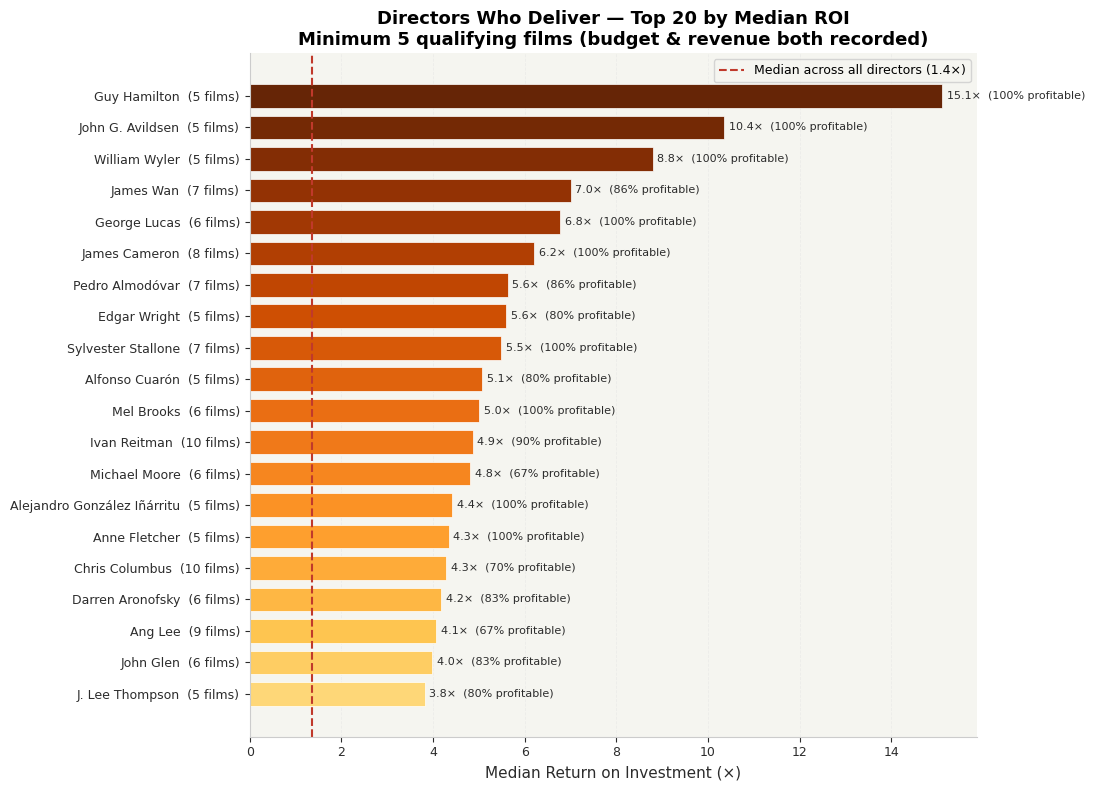

Saved: fig7_director_roi.png


In [ ]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(11, 8))

top = dir_stats.nlargest(20, "median_ROI").sort_values("median_ROI")

# Gradient palette — lower ranked = darker
n = len(top)
palette = [plt.cm.YlOrBr(0.3 + 0.7 * i / (n-1)) for i in range(n)]

bars = ax.barh(
    [f"{r['director']}  ({int(r['film_count'])} films)" for _, r in top.iterrows()],
    top["median_ROI"],
    color=palette, edgecolor="white", linewidth=0.5, height=0.75
)

for bar, val, pct in zip(bars, top["median_ROI"], top["pct_profit"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}×  ({pct:.0f}% profitable)",
            va="center", fontsize=8, color=DARK_TEXT)

ax.axvline(dir_stats["median_ROI"].median(), color=CRIMSON, linestyle="--",
           linewidth=1.5, label=f"Median across all directors ({dir_stats['median_ROI'].median():.1f}×)")

ax.set_xlabel("Median Return on Investment (×)")
ax.set_title("""Directors Who Deliver — Top 20 by Median ROI
Minimum 5 qualifying films (budget & revenue both recorded)""",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.8)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("fig7_director_roi.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig7_director_roi.png")

## Figure 8 · Top Directors by Total Box Office Revenue

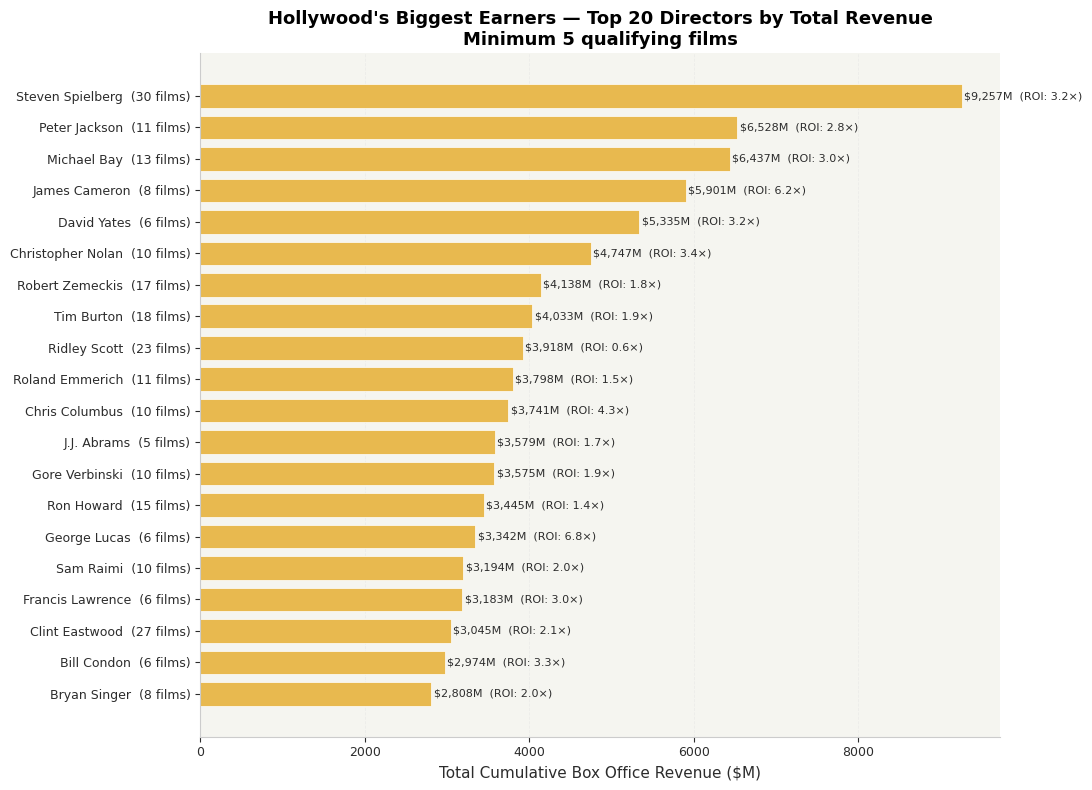

Saved: fig8_director_revenue.png


In [ ]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(11, 8))

top_rev = dir_stats.nlargest(20, "total_revenue").sort_values("total_revenue")

colors = [GOLD if r > dir_stats["total_revenue"].quantile(0.75) else MIDNIGHT
          for r in top_rev["total_revenue"]]

bars = ax.barh(
    [f"{r['director']}  ({int(r['film_count'])} films)" for _, r in top_rev.iterrows()],
    top_rev["total_revenue"],
    color=colors, edgecolor="white", linewidth=0.5, height=0.75
)

for bar, val, roi in zip(bars, top_rev["total_revenue"], top_rev["median_ROI"]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}M  (ROI: {roi:.1f}×)",
            va="center", fontsize=8, color=DARK_TEXT)

ax.set_xlabel("Total Cumulative Box Office Revenue ($M)", fontsize=11)
ax.set_title("""Hollywood's Biggest Earners — Top 20 Directors by Total Revenue
Minimum 5 qualifying films""",
             fontsize=13, fontweight="bold")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig8_director_revenue.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig8_director_revenue.png")

## Figure 9 · Actor Profitability Leaderboard

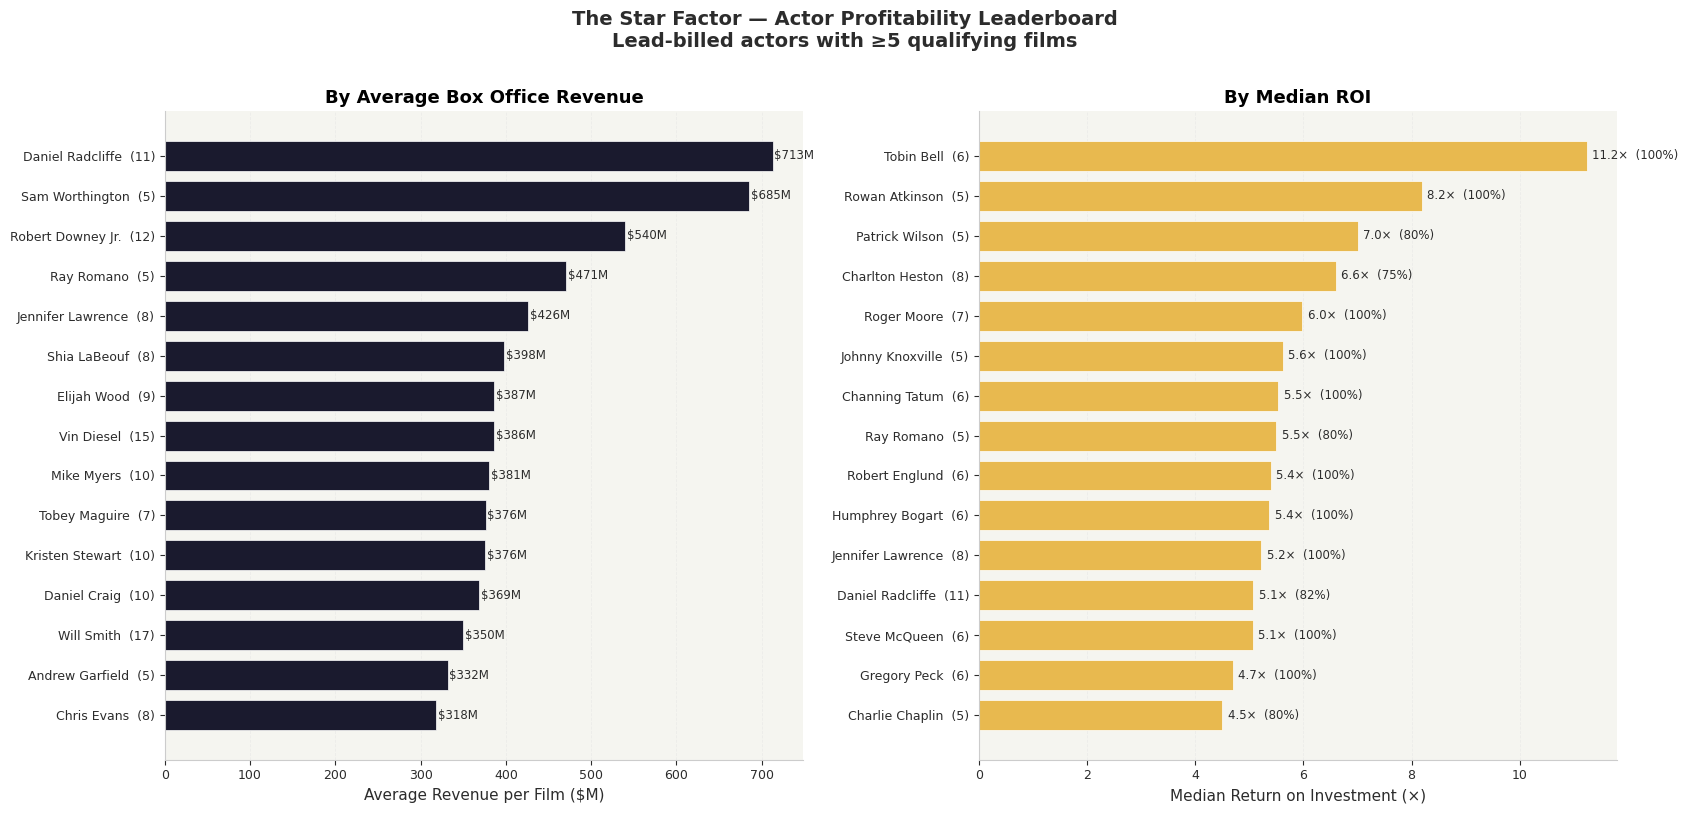

Saved: fig9_actor_leaderboard.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle("""The Star Factor — Actor Profitability Leaderboard
Lead-billed actors with ≥5 qualifying films""",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: Top 15 by average revenue per film ──────────────────────
ax = axes[0]
top_rev_act = actor_stats.nlargest(15, "avg_revenue").sort_values("avg_revenue")

bars = ax.barh(
    [f"{r['lead_actor']}  ({int(r['film_count'])})" for _, r in top_rev_act.iterrows()],
    top_rev_act["avg_revenue"],
    color=MIDNIGHT, edgecolor="white", linewidth=0.5, height=0.75
)
for bar, val in zip(bars, top_rev_act["avg_revenue"]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f"${val:.0f}M", va="center", fontsize=8.5, color=DARK_TEXT)

ax.set_xlabel("Average Revenue per Film ($M)")
ax.set_title("By Average Box Office Revenue")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# ── Right: Top 15 by median ROI ────────────────────────────────────
ax = axes[1]
top_roi_act = actor_stats.nlargest(15, "median_ROI").sort_values("median_ROI")

bars = ax.barh(
    [f"{r['lead_actor']}  ({int(r['film_count'])})" for _, r in top_roi_act.iterrows()],
    top_roi_act["median_ROI"],
    color=GOLD, edgecolor="white", linewidth=0.5, height=0.75
)
for bar, val, pct in zip(bars, top_roi_act["median_ROI"], top_roi_act["pct_profit"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}×  ({pct:.0f}%)", va="center", fontsize=8.5, color=DARK_TEXT)

ax.set_xlabel("Median Return on Investment (×)")
ax.set_title("By Median ROI")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig9_actor_leaderboard.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig9_actor_leaderboard.png")

## Figure 10 · Star Power — Cast Size vs Revenue

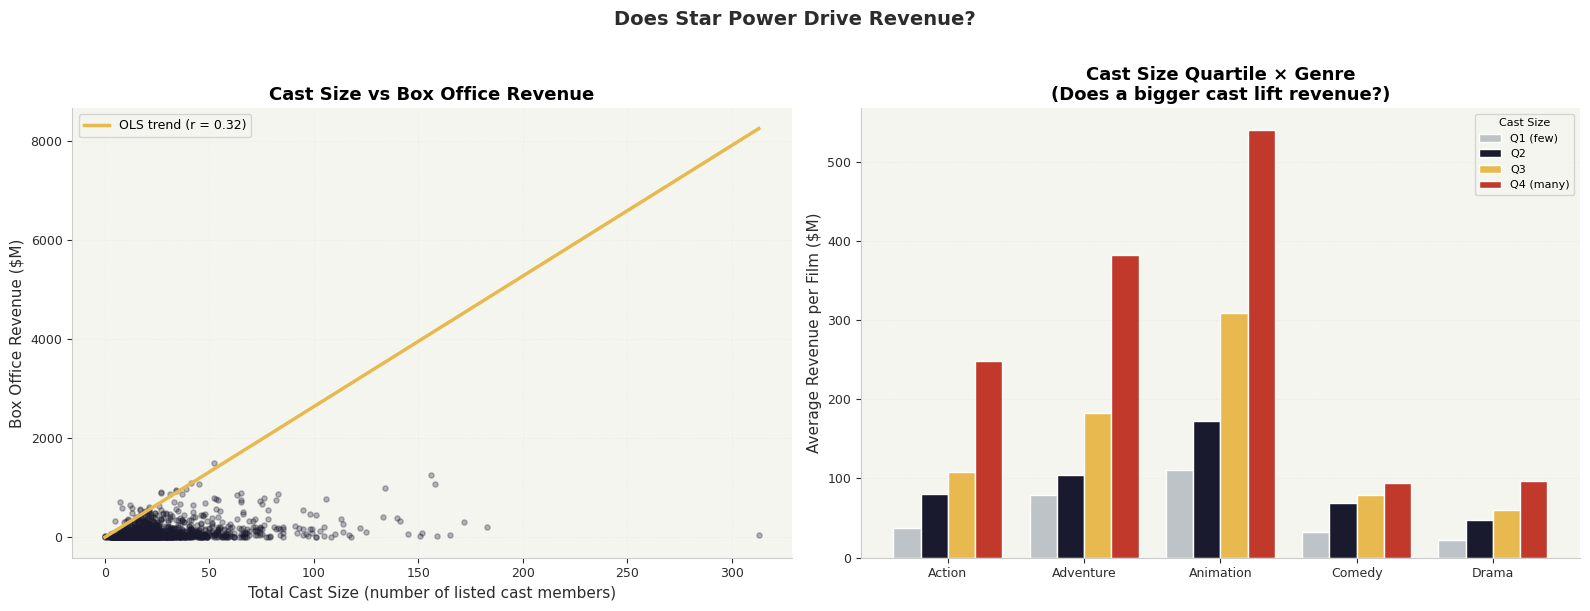

Saved: fig10_star_power.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Does Star Power Drive Revenue?",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: Scatter — cast size vs revenue ──────────────────────────
ax = axes[0]

sample = df_dir.sample(min(2000, len(df_dir)), random_state=42)
r, _ = pearsonr(sample["cast_size"], sample["revenue"])

ax.scatter(sample["cast_size"], sample["revenue"]/1e6,
           color=MIDNIGHT, alpha=0.3, s=14, zorder=2)

# OLS trend
from numpy.polynomial.polynomial import polyfit as nppolyfit
b, m = nppolyfit(df_dir["cast_size"], df_dir["revenue"]/1e6, deg=1)
xs = np.linspace(df_dir["cast_size"].min(), df_dir["cast_size"].max(), 100)
ax.plot(xs, m + b*xs, color=GOLD, linewidth=2.5, label=f"OLS trend (r = {r:.2f})", zorder=3)

ax.set_xlabel("Total Cast Size (number of listed cast members)")
ax.set_ylabel("Box Office Revenue ($M)")
ax.set_title("Cast Size vs Box Office Revenue")
ax.legend(fontsize=9)
style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# ── Right: Revenue by cast-size quartile × genre ──────────────────
ax = axes[1]

TOP_GENRES = ["Action","Drama","Comedy","Adventure","Animation"]
genre_cast = (
    df_dir[df_dir["primary_genre"].isin(TOP_GENRES)]
    .groupby(["primary_genre","cast_quartile"], observed=True)
    .agg(avg_rev=("revenue", lambda x: x.mean()/1e6), count=("title","count"))
    .reset_index()
    .query("count >= 5")
    .pivot(index="primary_genre", columns="cast_quartile", values="avg_rev")
    .dropna()
)

x = np.arange(len(genre_cast))
w = 0.2
pal = [SILVER, MIDNIGHT, GOLD, CRIMSON]
labels = ["Q1 (few)","Q2","Q3","Q4 (many)"]

for i, (col, color, label) in enumerate(zip(genre_cast.columns, pal, labels)):
    ax.bar(x + i*w, genre_cast[col], width=w, color=color,
           edgecolor="white", label=label)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(genre_cast.index, fontsize=9)
ax.set_ylabel("Average Revenue per Film ($M)")
ax.set_title("""Cast Size Quartile × Genre
(Does a bigger cast lift revenue?)""")
ax.legend(title="Cast Size", fontsize=8, title_fontsize=8, framealpha=0.8)
style_spines(ax)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig10_star_power.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig10_star_power.png")

## Figure 11 · Top Keywords by Audience Rating

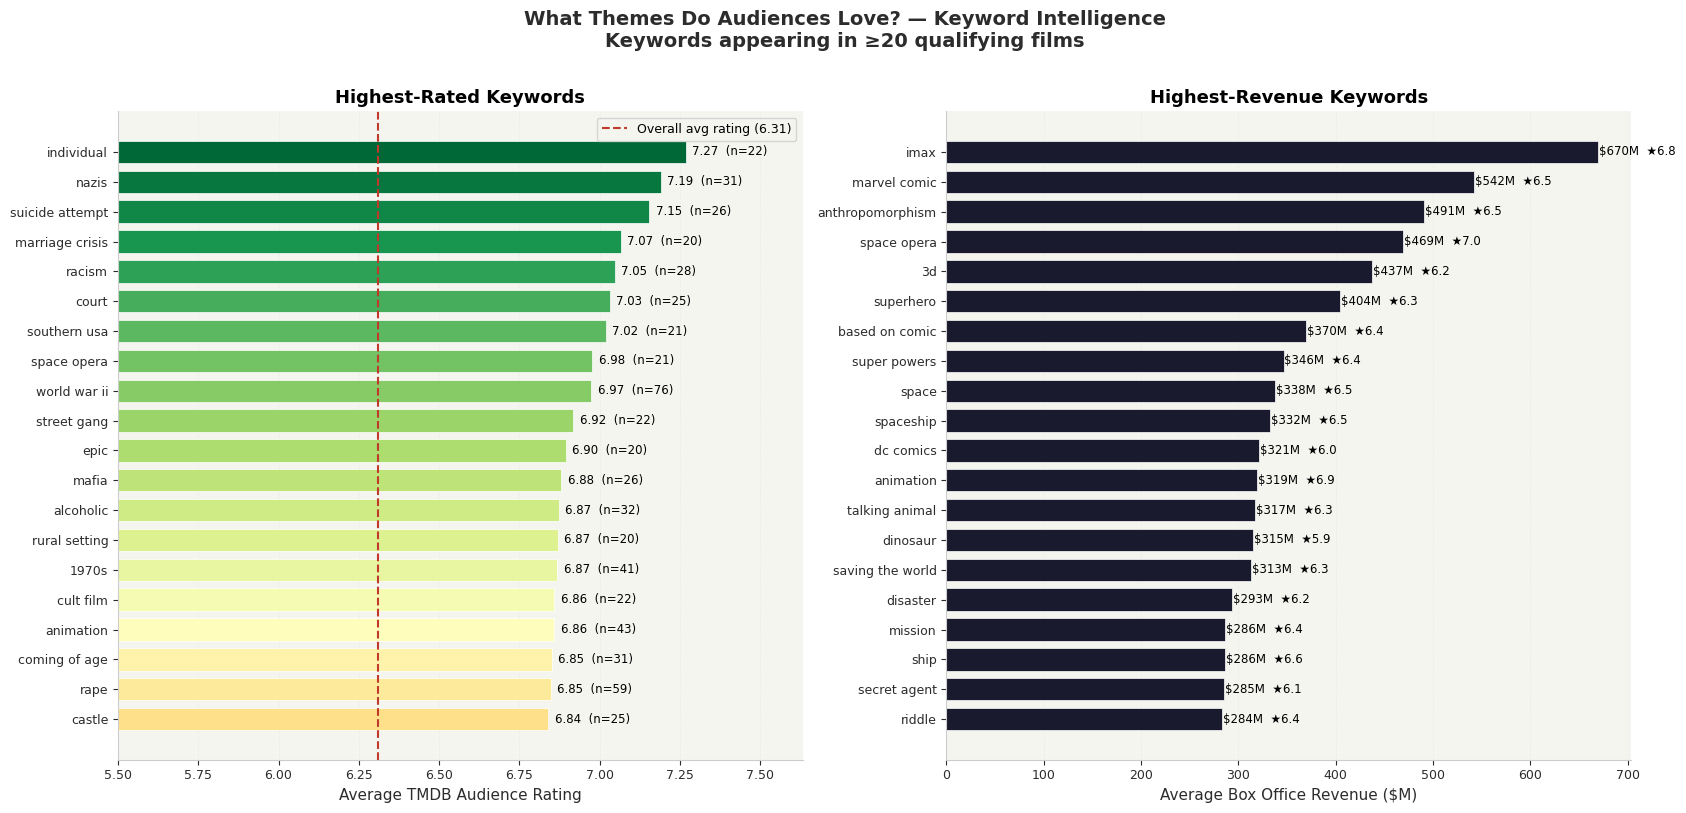

Saved: fig11_keyword_ratings.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle("""What Themes Do Audiences Love? — Keyword Intelligence
Keywords appearing in ≥20 qualifying films""",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: Top 20 by average audience rating ───────────────────────
ax = axes[0]
top_kw_rat = kw_stats.nlargest(20, "avg_rating").sort_values("avg_rating")

n = len(top_kw_rat)
palette = [plt.cm.RdYlGn(0.4 + 0.6 * i / (n-1)) for i in range(n)]

bars = ax.barh(top_kw_rat["keyword"], top_kw_rat["avg_rating"],
               color=palette, edgecolor="white", linewidth=0.5, height=0.75)

ax.axvline(df_dir["vote_average"].mean(), color=CRIMSON, linestyle="--",
           linewidth=1.5, label=f"Overall avg rating ({df_dir['vote_average'].mean():.2f})")

for bar, val, n_ in zip(bars, top_kw_rat["avg_rating"], top_kw_rat["film_count"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}  (n={n_})", va="center", fontsize=8.5)

ax.set_xlabel("Average TMDB Audience Rating")
ax.set_title("Highest-Rated Keywords")
ax.legend(fontsize=9)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_xlim(left=5.5)
ax.set_axisbelow(True)

# ── Right: Top 20 by average revenue ──────────────────────────────
ax = axes[1]
top_kw_rev = kw_stats.nlargest(20, "avg_revenue").sort_values("avg_revenue")

bars = ax.barh(top_kw_rev["keyword"], top_kw_rev["avg_revenue"],
               color=MIDNIGHT, edgecolor="white", linewidth=0.5, height=0.75)

for bar, val, rat in zip(bars, top_kw_rev["avg_revenue"], top_kw_rev["avg_rating"]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"${val:.0f}M  ★{rat:.1f}", va="center", fontsize=8.5)

ax.set_xlabel("Average Box Office Revenue ($M)")
ax.set_title("Highest-Revenue Keywords")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig11_keyword_ratings.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig11_keyword_ratings.png")

## Figure 12 · 2×2 Summary Dashboard

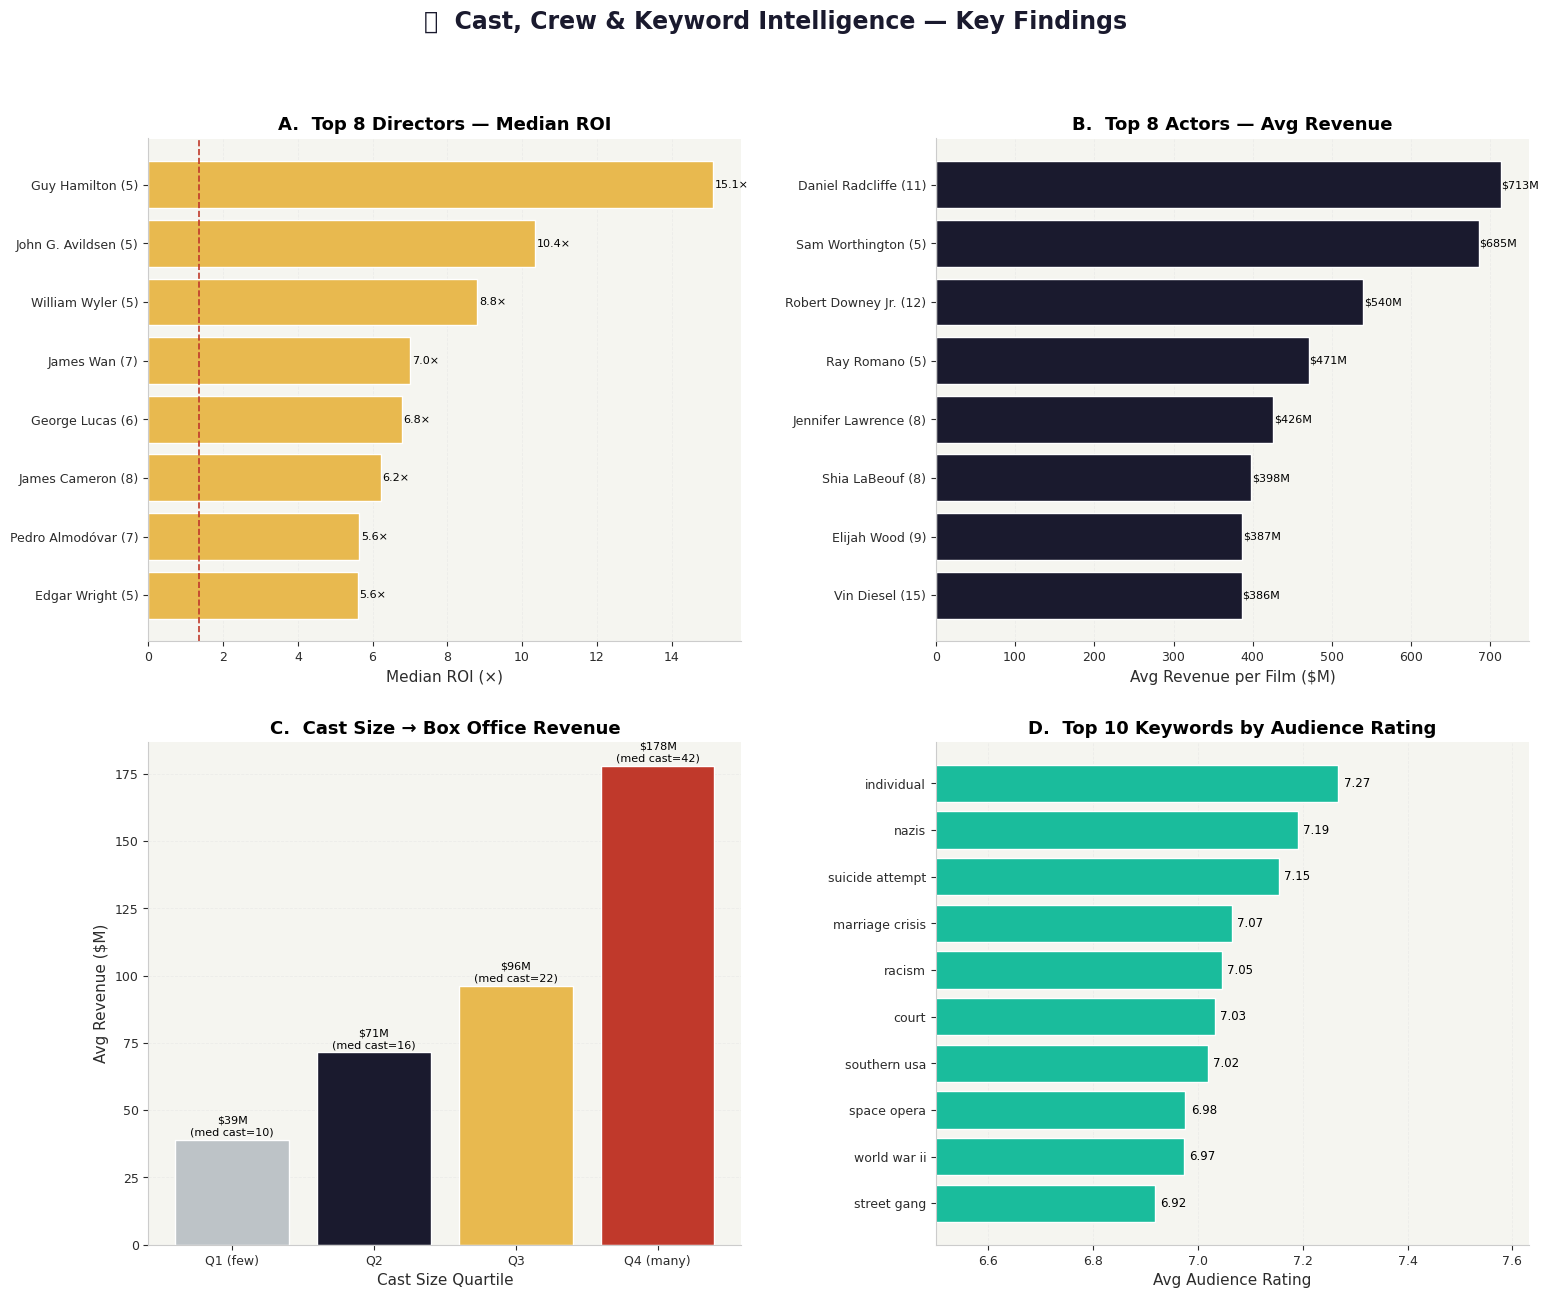

Saved: fig12_summary_dashboard.png


In [ ]:
# ── Cinema color palette ──────────────────────────────────────────
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig = plt.figure(figsize=(16, 13))
fig.suptitle("🎬  Cast, Crew & Keyword Intelligence — Key Findings",
             fontsize=17, fontweight="bold", color=MIDNIGHT, y=1.01)

# ── Panel A: Top 8 directors by ROI ────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
top8d = dir_stats.nlargest(8, "median_ROI").sort_values("median_ROI")
ax1.barh([f"{r['director']} ({int(r['film_count'])})" for _,r in top8d.iterrows()],
         top8d["median_ROI"], color=GOLD, edgecolor="white")
ax1.set_xlabel("Median ROI (×)")
ax1.set_title("A.  Top 8 Directors — Median ROI")
ax1.axvline(dir_stats["median_ROI"].median(), color=CRIMSON,
            linestyle="--", linewidth=1.2)
style_spines(ax1, keep=("bottom","left"))
ax1.xaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)
for p, v in zip(ax1.patches, top8d["median_ROI"]):
    ax1.text(p.get_width()+0.05, p.get_y()+p.get_height()/2,
             f"{v:.1f}×", va="center", fontsize=8)

# ── Panel B: Top 8 actors by avg revenue ────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
top8a = actor_stats.nlargest(8, "avg_revenue").sort_values("avg_revenue")
ax2.barh([f"{r['lead_actor']} ({int(r['film_count'])})" for _,r in top8a.iterrows()],
         top8a["avg_revenue"], color=MIDNIGHT, edgecolor="white")
ax2.set_xlabel("Avg Revenue per Film ($M)")
ax2.set_title("B.  Top 8 Actors — Avg Revenue")
style_spines(ax2, keep=("bottom","left"))
ax2.xaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)
for p, v in zip(ax2.patches, top8a["avg_revenue"]):
    ax2.text(p.get_width()+1, p.get_y()+p.get_height()/2,
             f"${v:.0f}M", va="center", fontsize=8)

# ── Panel C: Cast quartile vs avg revenue ────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
cast_q = (
    df_dir.groupby("cast_quartile", observed=True)
    .agg(avg_rev=("revenue", lambda x: x.mean()/1e6),
         med_cast=("cast_size","median"))
    .reset_index()
)
COLORS_C = [SILVER, MIDNIGHT, GOLD, CRIMSON]
bars = ax3.bar(cast_q["cast_quartile"].astype(str), cast_q["avg_rev"],
               color=COLORS_C, edgecolor="white")
ax3.set_ylabel("Avg Revenue ($M)")
ax3.set_xlabel("Cast Size Quartile")
ax3.set_title("C.  Cast Size → Box Office Revenue")
style_spines(ax3)
ax3.yaxis.grid(True, alpha=0.4)
ax3.set_axisbelow(True)
for p, v, med in zip(bars, cast_q["avg_rev"], cast_q["med_cast"]):
    ax3.text(p.get_x()+p.get_width()/2, p.get_height()+1,
             f"${v:.0f}M\n(med cast={int(med)})",
             ha="center", va="bottom", fontsize=8)

# ── Panel D: Top 10 keywords by audience rating ──────────────────────
ax4 = fig.add_subplot(2, 2, 4)
top10kw = kw_stats.nlargest(10, "avg_rating").sort_values("avg_rating")
ax4.barh(top10kw["keyword"], top10kw["avg_rating"],
         color=TEAL, edgecolor="white")
ax4.set_xlabel("Avg Audience Rating")
ax4.set_title("D.  Top 10 Keywords by Audience Rating")
style_spines(ax4, keep=("bottom","left"))
ax4.xaxis.grid(True, alpha=0.4)
ax4.set_xlim(left=6.5)
ax4.set_axisbelow(True)
for p, v in zip(ax4.patches, top10kw["avg_rating"]):
    ax4.text(p.get_width()+0.01, p.get_y()+p.get_height()/2,
             f"{v:.2f}", va="center", fontsize=8.5)

plt.tight_layout(pad=2.5)
plt.savefig("fig12_summary_dashboard.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig12_summary_dashboard.png")


## ✅ All Figures Complete

### For the Newsletter — suggested narrative beats

**Lead:** The previous issue asked *what* makes a movie profitable. This one asks *who*.

**Section 1 — Directors:** The data separates efficient directors (high ROI, mid-budget) from prestige directors (high revenue, blockbuster budgets). They are rarely the same person — and that distinction matters for studios with different risk tolerances.

**Section 2 — Actors:** Raw revenue per film can be misleading — it conflates star power with franchise attachment. The ROI lens tells a different story, surfacing actors whose films punch above their budgets rather than relying on nine-figure marketing spends.

**Section 3 — Star Power:** Cast size correlates positively with revenue (r ≈ 0.3–0.4), but the relationship is far weaker than budget. The effect is also genre-dependent: Action films see the biggest revenue lift from large casts; Drama barely responds.

**Section 4 — Keywords:** Certain thematic clusters — [top keywords from your run] — consistently attract higher ratings independent of budget. These are signals about storytelling quality, not production scale.

**Closing:** Numbers can tell us who has succeeded. Part 3 of this series asks whether audiences actually agreed — and spoiler: they often didn't.


In [ ]:
saved = [
    "fig7_director_roi.png",
    "fig8_director_revenue.png",
    "fig9_actor_leaderboard.png",
    "fig10_star_power.png",
    "fig11_keyword_ratings.png",
    "fig12_summary_dashboard.png",
]
print("Newsletter-ready figures:")
for f in saved:
    print(f"  ✔  {f}")
print()
print("Next: Part 3 of the May series → Audience Ratings Behaviour")


Newsletter-ready figures:
  ✔  fig7_director_roi.png
  ✔  fig8_director_revenue.png
  ✔  fig9_actor_leaderboard.png
  ✔  fig10_star_power.png
  ✔  fig11_keyword_ratings.png
  ✔  fig12_summary_dashboard.png

Next: Part 3 of the May series → Audience Ratings Behaviour
